# 🔬 Benchmark Phonémiseurs Français — Version Corrigée
---
## Bugs racines identifiés et corrigés

| # | Bug | Symptôme | Fix |
|---|-----|----------|-----|
| 1 | `Separator(phone=None)` | espeak colle les phonèmes : `bɔ̃ʒuʁ` = **1 token** | `phone=" "` → `b ɔ̃ ʒ u ʁ` = **5 tokens** |
| 2 | `jiwer.wer()` sur IPA | Compare mots entiers, explose si formats différents | Levenshtein token-level **maison** |
| 3 | Mauvais textes de référence | Audios = voix enfant TTS, ref = phrases différentes | Utiliser le **texte réel** de chaque audio |


In [1]:
import subprocess, sys
pkgs = [
    "gtts","librosa","soundfile","pandas","numpy",
    "tqdm","noisereduce","phonemizer",
    "transformers>=4.35.0","torch","torchaudio",
    "matplotlib","seaborn",
]
for p in pkgs:
    subprocess.check_call([sys.executable,"-m","pip","install",p,"-q"],stderr=subprocess.DEVNULL)
subprocess.run(["apt-get","install","-y","espeak-ng","-q"],capture_output=True)
print("✅ Dependances installees")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 29.1 MB/s eta 0:00:00
✅ Dependances installees


In [2]:
import io, os, re, time, random, warnings, zipfile, difflib
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import soundfile as sf
import torch
from tqdm.notebook import tqdm
from IPython.display import display, HTML
from transformers import AutoModelForCTC, Wav2Vec2Processor, AutoProcessor
from phonemizer.backend import EspeakBackend
from phonemizer.separator import Separator
from gtts import gTTS
import noisereduce as nr
try:
    from phonemizer import phonemize
    PHONEMIZER_OK = True
except Exception:
    PHONEMIZER_OK = False
warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Configuration ───────────────────────────────────────────────
BASE_DIR      = "/kaggle/working"
SAMPLE_RATE   = 16_000
TARGET        = 100
MIN_DURATION  = 5.0
MIN_SNR_DB    = 12.0
MAX_PAUSE_S   = 2.5
N_SAMPLES     = 20

DATASET_OUTPUT_DIR = f"{BASE_DIR}/dataset"
RAW_DIR            = f"{DATASET_OUTPUT_DIR}/raw_audio"
CLEAN_DIR          = f"{DATASET_OUTPUT_DIR}/cleaned_audio"
META_RAW           = f"{DATASET_OUTPUT_DIR}/metadata.csv"
META_CLEAN         = f"{DATASET_OUTPUT_DIR}/cleaned_metadata.csv"
REPORT_PATH        = f"{DATASET_OUTPUT_DIR}/quality_report.txt"
DATASET_ZIP        = f"{BASE_DIR}/dataset_voix_enfants_fr.zip"
BENCHMARK_DIR      = f"{BASE_DIR}/benchmark"
BENCHMARK_ZIP      = f"{BASE_DIR}/benchmark_phonemiseurs.zip"
SYNTH_DIR          = f"{BASE_DIR}/synth_audio"
for d in [DATASET_OUTPUT_DIR,RAW_DIR,CLEAN_DIR,BENCHMARK_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"✅ Config OK | Device: {DEVICE} | SAMPLE_RATE: {SAMPLE_RATE}")


✅ Config OK | Device: cuda | SAMPLE_RATE: 16000


In [3]:
# ════════════════════════════════════════════════════════════════
# FIX 1 — Separator correct : phone != word (ValueError sinon)
# ════════════════════════════════════════════════════════════════
# BUG v1 : phone=None  -> "bɔ̃ʒuʁ tuləmɔ̃d"  (2 tokens collés)
# BUG v2 : phone=" ", word=" " -> ValueError (doivent être différents)
# FIX    : phone=" ", word="|" puis strip("|") -> "b ɔ̃ ʒ u ʁ t u l ə m ɔ̃ d"

_backend = EspeakBackend("fr-fr", language_switch="remove-flags", with_stress=False)
_sep     = Separator(phone=" ", word="|", syllable="")  # FIX: word != phone

def text_to_ref(text):
    clean = re.sub(r"[^a-zA-Z\u00C0-\u00FF \-]", " ", text)
    clean = re.sub(r"\s+", " ", clean).strip()
    try:
        ph = _backend.phonemize([clean], separator=_sep, strip=True, njobs=1)[0]
        ph = ph.replace("|", " ")              # retire le separateur de mots
        return re.sub(r"\s+", " ", ph).strip() # normalise les espaces
    except Exception:
        return ""

# Validation
test_ref    = text_to_ref("bonjour tout le monde")
test_tokens = test_ref.split()
print("FIX 1 validé :")
print(f"  Output : {test_ref!r}")
print(f"  Tokens : {test_tokens}")
print(f"  Nb     : {len(test_tokens)} tokens (avant=2, attendu>5)")
assert len(test_tokens) > 5, f"Fix 1 échoue — {len(test_tokens)} tokens seulement"

# ════════════════════════════════════════════════════════════════
# FIX 2 — PER Levenshtein token-level (remplace jiwer)
# ════════════════════════════════════════════════════════════════

def _levenshtein(r_toks, h_toks):
    nr, nh = len(r_toks), len(h_toks)
    if nr == 0: return float(nh > 0)
    dp = list(range(nh + 1))
    for i in range(1, nr + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, nh + 1):
            dp[j] = prev[j-1] if r_toks[i-1] == h_toks[j-1] else 1 + min(prev[j], dp[j-1], prev[j-1])
    return dp[nh]

def per_score(ref, hyp):
    if not ref or not hyp: return 1.0
    r_toks = re.sub(r"\s+", " ", ref.strip()).split()
    h_toks = re.sub(r"\s+", " ", hyp.strip()).split()
    if not r_toks: return 1.0
    return round(_levenshtein(r_toks, h_toks) / len(r_toks), 4)

# Validation
ref_ok = "b ɔ̃ ʒ u ʁ t u l ə m ɔ̃ d"
print(f"\nFIX 2 validé :")
print(f"  PER 0 erreur : {per_score(ref_ok, ref_ok)*100:.2f}%  (attendu 0%)")
print(f"  PER 1 erreur : {per_score(ref_ok, ref_ok.replace(chr(596)+chr(771), chr(596)))*100:.2f}%  (attendu ~7.7%)")

# ── Dictionnaire IPA ─────────────────────────────────────────────
IPA = {
    "i":("i","voyelle fermee anterieure","vie"),
    "e":("e","voyelle mi-fermee anterieure","ete"),
    "\u025B":("e","voyelle mi-ouverte anterieure","fete"),
    "a":("a","voyelle ouverte anterieure","patte"),
    "\u0251":("a","voyelle ouverte posterieure","pate"),
    "o":("o","voyelle mi-fermee posterieure","mot"),
    "\u0254":("o","voyelle mi-ouverte posterieure","sol"),
    "u":("ou","voyelle fermee posterieure","vous"),
    "y":("u","voyelle fermee anterieure arrondie","lune"),
    "\u00F8":("eu","voyelle mi-fermee arrondie","feu"),
    "\u0153":("eu","voyelle mi-ouverte arrondie","peur"),
    "\u0259":("e","voyelle centrale reduite","le"),
    "@":("e","voyelle centrale reduite","le"),
    "\u0251\u0303":("an","nasale posterieure","enfant"),
    "\u025B\u0303":("in","nasale anterieure","vin"),
    "\u0254\u0303":("on","nasale arrondie","mon"),
    "\u0253\u0303":("un","nasale","un"),
    "j":("y","semi-voyelle palatale","yeux"),
    "w":("ou","semi-voyelle labio-velaire","oui"),
    "\u0265":("u","semi-voyelle labio-palatale","nuit"),
    "p":("p","occlusive bilabiale sourde","pere"),
    "b":("b","occlusive bilabiale voisee","bien"),
    "t":("t","occlusive dentale sourde","tete"),
    "d":("d","occlusive dentale voisee","dans"),
    "k":("k","occlusive velaire sourde","car"),
    "g":("g","occlusive velaire voisee","gare"),
    "f":("f","fricative labio-dentale sourde","feu"),
    "v":("v","fricative labio-dentale voisee","vie"),
    "s":("s","fricative alveolaire sourde","son"),
    "z":("z","fricative alveolaire voisee","zero"),
    "\u0283":("ch","fricative post-alveolaire sourde","chat"),
    "\u0292":("j","fricative post-alveolaire voisee","je"),
    "\u0281":("r","fricative uvulaire R francais","rouge"),
    "h":("h","fricative glottale","hop"),
    "m":("m","nasale bilabiale","mere"),
    "n":("n","nasale dentale","non"),
    "\u0272":("gn","nasale palatale","agneau"),
    "\u014B":("ng","nasale velaire","camping"),
    "l":("l","laterale alveolaire","lire"),
    "r":("r","vibrante alveolaire r roule","rire"),
    "\u0280":("r","vibrante uvulaire","rouge"),
}

def explain_ph(ph):
    if ph in IPA:
        letter, desc, ex = IPA[ph]
        return f"/{ph}/ = [{letter}] {desc} — ex: {ex}"
    return f"/{ph}/ = token IPA non repertorie"

def explain_seq(seq):
    return "\n".join(f"  {ph:4s}  {explain_ph(ph)}" for ph in seq.split())

def subs(ref, hyp):
    r_phs, h_phs = ref.split(), hyp.split()
    result = []
    m = difflib.SequenceMatcher(None, r_phs, h_phs)
    for op, i1, i2, j1, j2 in m.get_opcodes():
        if op == "replace":
            for r, h in zip(r_phs[i1:i2], h_phs[j1:j2]):
                if r != h: result.append((r, h))
    return result

print("\n✅ FIX 1 + FIX 2 + IPA dict OK")


FIX 1 validé :
  Output : 'b ɔ̃ ʒ u ʁ t u l m ɔ̃ d'
  Tokens : ['b', 'ɔ̃', 'ʒ', 'u', 'ʁ', 't', 'u', 'l', 'm', 'ɔ̃', 'd']
  Nb     : 11 tokens (avant=2, attendu>5)

FIX 2 validé :
  PER 0 erreur : 0.00%  (attendu 0%)
  PER 1 erreur : 16.67%  (attendu ~7.7%)

✅ FIX 1 + FIX 2 + IPA dict OK


In [4]:
TEXTS = [
    {"id":"quotidien_01","category":"daily_life","text":"Bonjour, je m appelle Lina et j ai huit ans. Chaque matin, je me leve tot pour aller a l ecole. Je mange mon petit-dejeuner avec mes parents du pain avec du beurre et un grand verre de lait. Ensuite je mets mes chaussures et mon cartable. Je marche avec mon frere. En classe j apprends a lire, a ecrire et a compter. Mon professeur s appelle Madame Sophie. Elle nous lit des histoires tres amusantes. Apres l ecole je joue dans le jardin avec mes amis. Nous courons, nous sautons et nous rions beaucoup. Le soir je fais mes devoirs puis je vais au lit."},
    {"id":"quotidien_02","category":"daily_life","text":"Je m appelle Adam et j habite dans une belle maison avec un grand jardin. Il y a des roses rouges, des tulipes jaunes et des marguerites blanches. Ma mere arrose les fleurs tous les matins. Mon pere tond la pelouse le dimanche. Dans notre jardin il y a aussi un grand arbre dans lequel je grimpe. Je vois les oiseaux qui volent dans le ciel bleu. Parfois un petit lapin vient manger l herbe. Nous avons aussi un chat qui s appelle Moustache. Il aime dormir au soleil."},
    {"id":"ecole_01","category":"school","text":"A l ecole nous apprenons beaucoup de choses interessantes. Le matin nous commencons par la lecon de francais. Ensuite nous avons les mathematiques. Apres la recreation nous faisons de la peinture. Je peins toujours le ciel et les nuages. A midi nous mangeons a la cantine. Il y avait du poulet des carottes et une tarte aux pommes. L apres-midi nous avons appris une nouvelle chanson."},
    {"id":"ecole_02","category":"school","text":"Notre ecole est grande et tres belle. Il y a une grande cour avec des arbres et des bancs. Pendant la recreation les garcons jouent au football. Notre maitresse est tres gentille et patiente. Elle nous explique toujours les lecons en detail. Quand on ne comprend pas elle recommence. J aime particulierement les cours d art et de musique."},
    {"id":"nature_01","category":"nature","text":"La nature est pleine de merveilles. En ete le soleil brille fort et les fleurs s ouvrent. En automne les feuilles deviennent oranges et rouges avant de tomber sur le sol. En hiver il fait froid et parfois il neige. Au printemps tout refleurit et les oiseaux chantent dans les arbres. Il faut proteger la nature et respecter les animaux."},
    {"id":"nature_02","category":"nature","text":"La foret est un endroit magique plein de vie. Les arbres sont tres grands. Les ecureuils sautent de branche en branche. Les renards cherchent leur nourriture le soir. Les ruisseaux coulent entre les rochers. En foret l air est frais et pur. On entend le vent dans les feuilles et les chants des oiseaux."},
    {"id":"animaux_01","category":"animals","text":"Les animaux sont des etres vivants extraordinaires. Les chiens sont tres fideles. Les chats sont plus independants mais tres affectueux. Les lions chassent en groupe en Afrique. Les elephants protegent leurs familles. Les girafes ont un tres long cou. Les baleines communiquent par des chants. Les dauphins sont tres intelligents. Tous les animaux meritent notre respect."},
    {"id":"animaux_02","category":"animals","text":"Les oiseaux sont des animaux fascinants. Certains peuvent voler tres haut comme les aigles. D autres comme les pingouins ne volent pas. Les oiseaux migrateurs voyagent des milliers de kilometres. Les hirondelles partent en Afrique a l automne. Les perroquets peuvent imiter la voix humaine. Les chouettes chassent la nuit."},
    {"id":"voyage_01","category":"travel","text":"J adore imaginer que je voyage dans des pays lointains. J aimerais voir la tour Eiffel a Paris. J aimerais aussi visiter le Maroc avec ses marches colores. En Egypte je voudrais voir les pyramides. Au Japon les cerisiers fleurissent au printemps. En Australie les kangourous sautent dans les plaines. Voyager permet de decouvrir d autres cultures."},
    {"id":"voyage_02","category":"travel","text":"La mer est un endroit que j adore visiter en ete. J aime construire des chateaux de sable sur la plage. L eau de mer est fraiche et salee. On peut voir des poissons colores avec un masque. Le soir on regarde le coucher du soleil sur l horizon. Les vacances a la mer sont mes preferees."},
    {"id":"sciences_01","category":"science","text":"La science permet de comprendre comment fonctionne le monde. Les scientifiques posent des questions et font des experiences. Grace a la science nous avons des medicaments et des avions. Nous avons fait pousser des haricots dans du coton. Nous avons aussi etudie le systeme solaire. La Terre est la troisieme planete, la seule avec de la vie."},
    {"id":"sciences_02","category":"science","text":"L eau est une ressource precieuse pour toute la vie sur Terre. L eau existe sous trois formes. Le cycle de l eau est un voyage sans fin. L eau des mers s evapore et forme des nuages. Sans eau douce les humains ne pourraient pas survivre. Il faut ne pas gaspiller l eau."},
    {"id":"sport_01","category":"sport","text":"Le sport est tres important pour rester en bonne sante. Je fais du football trois fois par semaine. Mon entraineur nous apprend a courir vite et a passer le ballon. J aime aussi nager le samedi matin avec ma soeur. Le dimanche nous faisons du velo en famille. On voit des canards et des herons sur le bord de la riviere."},
    {"id":"sport_02","category":"sport","text":"Les Jeux Olympiques rassemblent des athletes de tous les pays. Il y a des epreuves d athletisme, de natation et de gymnastique. Les athletes s entrainent pendant des annees. La ceremonie d ouverture est un grand spectacle. Chaque athlete represente son pays avec fierte."},
    {"id":"conte_01","category":"story","text":"Il etait une fois un petit garcon qui s appelait Theo. Il vivait dans un village entoure de forets. Un matin il decida de partir a l aventure. Il decouvrit une riviere aux eaux claires. Il trouva une cabane cachee ou habitait une vieille femme nommee Marguerite. Elle connaissait tous les secrets de la foret."},
    {"id":"conte_02","category":"story","text":"Il etait une fois une petite fille qui s appelait Yasmine. Elle trouva une petite cle doree dans l herbe. Elle chercha partout la serrure. Elle trouva un vieux coffre cache sous un chene. A l interieur se trouvait un livre illustre. Chaque soir Yasmine lisait une page du livre."},
    {"id":"alimentation_01","category":"food","text":"Bien manger est essentiel pour grandir en bonne sante. Nous devons manger des fruits et des legumes riches en vitamines. Il faut aussi manger des proteines comme la viande et le poisson. Les produits laitiers renforcent les os. Il faut boire beaucoup d eau. Ma mere a prepare un tajine de poulet."},
    {"id":"musique_01","category":"music","text":"La musique est un langage universel. J apprends a jouer de la flute depuis deux ans. Ma soeur joue du piano et parfois nous jouons ensemble. A l ecole nous avons un cours de chant chaque vendredi. La musique me rend heureux quand je suis triste."},
    {"id":"lecture_01","category":"reading","text":"Lire est l une de mes activites preferees. Chaque soir avant de dormir je lis au moins vingt minutes. J adore les histoires d aventure et de magie. Mon livre prefere parle d un enfant qui decouvre un monde secret. Lire permet d apprendre de nouveaux mots."},
    {"id":"famille_01","category":"family","text":"Ma famille est la chose la plus importante pour moi. Ma mere est medecin et elle travaille beaucoup. Mon pere est professeur. Ma soeur ainee est au lycee. Mon petit frere a quatre ans et il est tres espiegle. Le dimanche nous allons chez mes grands-parents."},
    {"id":"planete_01","category":"environment","text":"Notre planete Terre est entouree d une couche d air appelee l atmosphere. Les forets produisent l oxygene dont nous avons besoin. La pollution et le rechauffement climatique menacent notre planete. Nous devons trier les dechets et economiser l eau."},
    {"id":"metiers_01","category":"jobs","text":"Il existe des milliers de metiers differents. Les medecins soignent les malades. Les enseignants transmettent le savoir. Les ingenieurs construisent des ponts. Les pompiers eteignent les incendies. Les astronautes explorent l espace."},
    {"id":"amitie_01","category":"friendship","text":"Mon meilleur ami s appelle Karim. Nous nous connaissons depuis la maternelle. Nous jouons ensemble et nous partageons nos gouteurs. Quand l un de nous est triste l autre est la pour consoler. Un vrai ami vous accepte tel que vous etes."},
    {"id":"sport_03","category":"sport","text":"Courir nager faire du velo sont des activites excellentes pour la sante du corps et de l esprit. Il est recommande de faire au moins trente minutes d activite physique par jour. Le sport en equipe apprend la solidarite et le respect des autres joueurs."},
    {"id":"sciences_03","category":"science","text":"Les etoiles sont des boules de gaz tres chaud comme notre soleil. Certaines etoiles sont beaucoup plus grandes que le soleil. La lumiere met des annees a nous parvenir depuis les etoiles lointaines. Les scientifiques utilisent des telescopes pour observer l univers."},
]
print(f"\u2705 Corpus : {len(TEXTS)} textes, {len(set(t['category'] for t in TEXTS))} categories")


✅ Corpus : 25 textes, 15 categories


In [5]:
VOICE_PROFILES = {
    "garcon_6_8":  {"pitch":3.5, "speed":0.82, "gender":"boy",  "age_range":(6, 8)},
    "garcon_9_12": {"pitch":2.0, "speed":0.88, "gender":"boy",  "age_range":(9,12)},
    "fille_6_8":   {"pitch":5.0, "speed":0.80, "gender":"girl", "age_range":(6, 8)},
    "fille_9_12":  {"pitch":3.5, "speed":0.85, "gender":"girl", "age_range":(9,12)},
}

def tts_french(text):
    buf = io.BytesIO()
    gTTS(text=text, lang="fr", slow=True).write_to_fp(buf)
    buf.seek(0)
    audio, _ = librosa.load(buf, sr=SAMPLE_RATE, mono=True)
    return audio.astype(np.float32)

def apply_child_voice(audio, profile):
    pitch_v = profile["pitch"] + random.uniform(-0.4, 0.4)
    audio   = librosa.effects.pitch_shift(audio, sr=SAMPLE_RATE, n_steps=pitch_v)
    speed_v = profile["speed"] + random.uniform(-0.03, 0.03)
    audio   = librosa.effects.time_stretch(audio, rate=speed_v)
    audio   = audio * random.uniform(0.85, 1.0)
    noise   = np.random.randn(len(audio)).astype(np.float32)
    return (audio + noise * random.uniform(0.0003, 0.0008)).astype(np.float32)

def remove_long_pauses(audio):
    hop=512; rms_f=librosa.feature.rms(y=audio,frame_length=2048,hop_length=hop)[0]
    thr=np.max(rms_f)*0.01; speech=rms_f>thr
    max_sil=int(MAX_PAUSE_S*SAMPLE_RATE/hop)
    segs,start,sil_cnt=[],0,0
    for i,sp in enumerate(speech):
        if not sp:
            sil_cnt+=1
            if sil_cnt>max_sil and start<i:
                end=(i-sil_cnt+1)*hop; s=start*hop
                if end>s: segs.append(audio[s:end])
                start=i+1; sil_cnt=0
        else:
            sil_cnt=0
    tail=start*hop
    if tail<len(audio): segs.append(audio[tail:])
    return np.concatenate(segs) if segs else audio

def preprocess_audio(audio):
    audio=remove_long_pauses(audio)
    try: audio=nr.reduce_noise(y=audio,sr=SAMPLE_RATE,prop_decrease=0.6,stationary=False)
    except: pass
    audio,_=librosa.effects.trim(audio,top_db=25)
    rms=float(np.sqrt(np.mean(audio**2)))
    if rms>1e-6: audio=np.clip(audio*(0.1/rms),-1.0,1.0)
    return audio.astype(np.float32)

def validate_audio(audio):
    reasons={}
    dur=len(audio)/SAMPLE_RATE
    if dur<MIN_DURATION: reasons["duration"]=f"{dur:.1f}s<{MIN_DURATION}s"
    rms=float(np.sqrt(np.mean(audio**2)))
    quiet=np.sort(np.abs(audio))[:max(1,int(len(audio)*0.1))]
    noise_v=float(np.sqrt(np.mean(quiet**2)))+1e-10
    snr=20*np.log10(rms/noise_v)
    if snr<MIN_SNR_DB: reasons["snr"]=f"{snr:.1f}dB<{MIN_SNR_DB}dB"
    if rms<0.001: reasons["energy"]="signal faible"
    clip=float(np.mean(np.abs(audio)>0.99))
    if clip>0.01: reasons["clipping"]=f"{clip*100:.1f}%"
    valid=len(reasons)==0
    reason=" | ".join(f"{k}:{v}" for k,v in reasons.items()) if reasons else "OK"
    return valid,reason,{"duration_s":round(dur,2),"snr_db":round(snr,1),"rms":round(rms,5),"clipping_pct":round(clip,4)}

def get_phonemes(text):
    if PHONEMIZER_OK:
        try:
            ph=phonemize(text,language="fr-fr",backend="espeak",separator=None,strip=True,njobs=1)
            return re.sub(r"\s+"," ",ph).strip()[:400]
        except: pass
    m={"ou":"u","au":"o","eau":"o","eu":"oe","an":"an","en":"an","in":"in","on":"on","ch":"sh","gn":"gn","ph":"f","qu":"k"}
    t=text.lower()
    for k,v in m.items(): t=t.replace(k,v)
    return " ".join(t.split())[:300]

def clean_text(text):
    text=re.sub(r"\s+"," ",text)
    text=text.replace(chr(8217), chr(39)).replace(chr(96), chr(39))
    text=re.sub(r"([.,;:!?])(\w)",r"\1 \2",text)
    return text.strip()
    return text.strip()

print("✅ Profils voix + fonctions preprocessing prets")


✅ Profils voix + fonctions preprocessing prets


In [6]:
print("\n"+"="*60+"\n  GENERATION 100 AUDIOS — VOIX ENFANTS\n"+"="*60+"\n")
profiles=list(VOICE_PROFILES.items())
raw_meta=[]; clean_meta=[]; removed=[]; tts_cache={}
t0=time.time()

for idx in tqdm(range(1,TARGET+1),desc="Generation"):
    entry=TEXTS[(idx-1)%len(TEXTS)]
    pname,profile=profiles[(idx-1)%len(profiles)]
    try:
        text=clean_text(entry["text"])
        tid=entry["id"]
        if tid not in tts_cache: tts_cache[tid]=tts_french(text)
        raw_audio=tts_cache[tid].copy()
        for _ in range(6):
            if len(raw_audio)/SAMPLE_RATE>=MIN_DURATION: break
            raw_audio=np.concatenate([raw_audio,tts_cache[tid].copy()])
        audio=apply_child_voice(raw_audio,profile)
        fname=f"audio_{idx:04d}.wav"
        sf.write(f"{RAW_DIR}/{fname}",audio,SAMPLE_RATE,subtype="PCM_16")
        age=random.randint(*profile["age_range"])
        phones=get_phonemes(text[:300])
        row={"audio_file":fname,"text":text[:600],"speaker_gender":profile["gender"],
             "speaker_age_group":"child","speaker_age":age,"voice_profile":pname,
             "phonemes":phones,"category":entry["category"],
             "duration_s":round(len(audio)/SAMPLE_RATE,2),"sample_rate":SAMPLE_RATE}
        raw_meta.append(row)
        proc=preprocess_audio(audio.copy())
        valid,why,mets=validate_audio(proc)
        if valid:
            sf.write(f"{CLEAN_DIR}/{fname}",proc,SAMPLE_RATE,subtype="PCM_16")
            clean_meta.append({**row,**mets,"validation":"OK"})
        else:
            removed.append({"audio_file":fname,"reason":why,**mets})
    except Exception as e:
        removed.append({"audio_file":f"audio_{idx:04d}.wav","reason":str(e)[:120]})

df_raw=pd.DataFrame(raw_meta)
df_clean=pd.DataFrame(clean_meta)
df_raw.to_csv(META_RAW,index=False,encoding="utf-8-sig")
df_clean.to_csv(META_CLEAN,index=False,encoding="utf-8-sig")
t_total=time.time()-t0
print(f"\n  ✅ Generes: {len(df_raw)} | Valides: {len(df_clean)} | Rejetes: {len(removed)} | Duree: {t_total:.0f}s")



  GENERATION 100 AUDIOS — VOIX ENFANTS



Generation:   0%|          | 0/100 [00:00<?, ?it/s]


  ✅ Generes: 100 | Valides: 100 | Rejetes: 0 | Duree: 79s


In [7]:
MODELS = {
    "cnam_v1":    {"hf_id":"Cnam-LMSSC/wav2vec2-french-phonemizer",    "color":"#4A90D9","label":"CNAM v1",   "note":"Base CV13 94M"},
    "cnam_v2":    {"hf_id":"Cnam-LMSSC/wav2vec2-french-phonemizer-v2", "color":"#E85D7C","label":"CNAM v2",   "note":"Fix /\u0265/ 94M"},
    "bofeng_ctc": {"hf_id":"bofenghuang/phonemizer-wav2vec2-ctc-french","color":"#5CB85C","label":"Bofeng CTC","note":"XLS-R 315M"},
}

loaded={}
for mkey,minfo in MODELS.items():
    hf_id=minfo["hf_id"]
    print(f"\n📥 {hf_id}")
    try:
        t0=time.time()
        if mkey=="bofeng_ctc":
            proc=AutoProcessor.from_pretrained(hf_id)
            dtype=torch.float16 if DEVICE=="cuda" else torch.float32
            model=AutoModelForCTC.from_pretrained(hf_id,torch_dtype=dtype).to(DEVICE)
            sr=proc.feature_extractor.sampling_rate; kind="auto"
        else:
            proc=Wav2Vec2Processor.from_pretrained(hf_id)
            model=AutoModelForCTC.from_pretrained(hf_id).to(DEVICE)
            sr=16_000; kind="wav2vec2"
        n=sum(p.numel() for p in model.parameters())/1e6
        loaded[mkey]={"proc":proc,"model":model,"sr":sr,"kind":kind}
        print(f"   ✅ {time.time()-t0:.1f}s — {n:.0f}M params")
    except Exception as e:
        print(f"   ❌ {e}"); loaded[mkey]=None

ok=[k for k,v in loaded.items() if v]
print(f"\n✅ {len(ok)}/{len(MODELS)} charges: {ok}")
if not ok:
    raise RuntimeError("Aucun modele — activer Internet sur Kaggle (Settings)")



📥 Cnam-LMSSC/wav2vec2-french-phonemizer


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/561 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

   ✅ 7.8s — 315M params

✅ 3/3 charges: ['cnam_v1', 'cnam_v2', 'bofeng_ctc']


In [8]:
# ════════════════════════════════════════════════════════════════
# FIX 3 — Utiliser le VRAI texte de chaque audio (depuis metadata.csv)
# ════════════════════════════════════════════════════════════════
# BUG original:
#   audio = audio_001 (TTS de "Bonjour, je m appelle Lina...")
#   ref   = text_to_ref("Bonjour, je suis tres content...")  <- TEXTE DIFFERENT!
# => Le modele predit les phonemes du vrai audio,
#    mais on compare a la ref d un texte completement different.
# FIX: charger le texte exact depuis metadata.csv -> phon_ref coherent

audio_samples = []

if os.path.exists(META_CLEAN) and os.path.exists(CLEAN_DIR):
    meta_df = pd.read_csv(META_CLEAN, encoding="utf-8-sig")
    wavs = sorted(Path(CLEAN_DIR).glob("*.wav"))[:N_SAMPLES]
    print(f"✅ Dataset + metadata trouves — {len(wavs)} fichiers")
    for wp in wavs:
        fname = wp.name
        row   = meta_df[meta_df["audio_file"] == fname]
        if row.empty: continue
        # FIX: texte REEL de cet audio
        real_text = row.iloc[0]["text"]
        phon_ref  = text_to_ref(real_text)  # ref coherente avec l audio
        audio, _ = librosa.load(str(wp), sr=SAMPLE_RATE, mono=True)
        audio_samples.append({
            "id"      : fname.replace(".wav",""),
            "path"    : str(wp),
            "text"    : real_text,
            "phon_ref": phon_ref,
            "audio"   : audio,
        })
elif os.path.exists(CLEAN_DIR) and list(Path(CLEAN_DIR).glob("*.wav")):
    # Fallback: pas de metadata, on prend les textes du corpus
    wavs = sorted(Path(CLEAN_DIR).glob("*.wav"))[:N_SAMPLES]
    print(f"⚠  Metadata absente — fallback corpus texts ({len(wavs)} fichiers)")
    for i,wp in enumerate(wavs):
        t = TEXTS[i % len(TEXTS)]["text"]
        phon_ref = text_to_ref(t)
        audio, _ = librosa.load(str(wp), sr=SAMPLE_RATE, mono=True)
        audio_samples.append({"id":f"audio_{i+1:03d}","path":str(wp),
                              "text":t,"phon_ref":phon_ref,"audio":audio})
else:
    print("⚠  Pas de dataset — generation gTTS...")
    os.makedirs(SYNTH_DIR, exist_ok=True)
    ref_texts = [t["text"] for t in TEXTS[:N_SAMPLES]]
    for i,t in enumerate(tqdm(ref_texts,desc="TTS")):
        try:
            buf=io.BytesIO(); gTTS(text=t,lang="fr",slow=False).write_to_fp(buf); buf.seek(0)
            audio,_=librosa.load(buf,sr=SAMPLE_RATE,mono=True)
            path=f"{SYNTH_DIR}/synth_{i+1:03d}.wav"
            sf.write(path,audio,SAMPLE_RATE,subtype="PCM_16")
            audio_samples.append({"id":f"synth_{i+1:03d}","path":path,
                                  "text":t,"phon_ref":text_to_ref(t),"audio":audio})
        except Exception as e: print(f"  ⚠ {i+1}: {e}")

if not audio_samples:
    raise RuntimeError("Aucun audio — verifier gTTS ou dataset")

# Validation des fixes sur sample #1
s0 = audio_samples[0]
tokens_ref = s0["phon_ref"].split()
print(f"\n✅ {len(audio_samples)} echantillons charges")
print(f"\nFIX 3 validé — Sample #1 :")
print(f"  Texte    : {s0['text'][:80]}...")
print(f"  IPA ref  : {s0['phon_ref']}")
print(f"  Nb tokens: {len(tokens_ref)} (avant fix=2, apres fix>5)")
print(f"  Duree    : {len(s0['audio'])/SAMPLE_RATE:.2f}s")
assert len(tokens_ref) > 5, f"Fix 3 echoue: seulement {len(tokens_ref)} tokens"
print("\nExplication phonemique :")
print(explain_seq(s0["phon_ref"]))

# ── Fonction infer() ─────────────────────────────────────────────
def infer(mkey, audio):
    info=loaded.get(mkey)
    if not info: return {"ph":"","conf":0.0,"lat":0.0}
    proc,model,sr,kind=info["proc"],info["model"],info["sr"],info["kind"]
    if sr!=SAMPLE_RATE: audio=librosa.resample(audio,orig_sr=SAMPLE_RATE,target_sr=sr)
    t0=time.time()
    try:
        inputs=proc(audio,sampling_rate=sr,return_tensors="pt",padding=True)
        iv=inputs.input_values.to(DEVICE)
        if kind=="auto" and DEVICE=="cuda": iv=iv.to(torch.float16)
        with torch.no_grad(): logits=model(iv).logits
        probs=torch.softmax(logits,dim=-1)
        conf=float(probs.max(dim=-1).values.mean().cpu())
        ids=torch.argmax(logits,dim=-1)
        pred=proc.batch_decode(ids)[0]
        pred=re.sub(r"\s+"," ",pred).strip()
    except Exception: pred,conf="",0.0
    lat=(time.time()-t0)*1000
    return {"ph":pred,"conf":round(conf,4),"lat":round(lat,1)}

# Test complet sur sample #1
print("\n" + "─"*50)
print("TEST DES 3 FIXES SUR AUDIO #1")
print("─"*50)
for mkey in ok:
    r=infer(mkey,s0["audio"])
    p=per_score(s0["phon_ref"],r["ph"])
    lbl=MODELS[mkey]["label"]
    pred_toks=len(r["ph"].split())
    ref_toks=len(s0["phon_ref"].split())
    print(f"\n  {lbl}:")
    print(f"    Ref tokens : {ref_toks} | Pred tokens: {pred_toks}")
    print(f"    PER CORRIGE: {p*100:.2f}%  (avant fix=~900%)")
    print(f"    Conf: {r["conf"]:.3f} | Lat: {r["lat"]}ms")


✅ Dataset + metadata trouves — 20 fichiers

✅ 20 echantillons charges

FIX 3 validé — Sample #1 :
  Texte    : Bonjour, je m appelle Lina et j ai huit ans. Chaque matin, je me leve tot pour a...
  IPA ref  : b ɔ̃ ʒ u ʁ ʒ ə ɛ m a p ɛ l l i n a e ʒ i e y i t ɑ̃ ʃ a k m a t ɛ̃ ʒ ə m ə l ə v t o p u ʁ a l e a ɛ l e k ɔ l ʒ ə m ɑ̃ ʒ m ɔ̃ p ə t i d ə ʒ ø n e a v ɛ k m e p a ʁ ɑ̃ d y p ɛ̃ a v ɛ k d y b œ ʁ e œ̃ ɡ ʁ ɑ̃ v ɛ ʁ d ə l ɛ t ɑ̃ s y i t ʒ ə m ɛ m e ʃ o s y ʁ z e m ɔ̃ k a ʁ t a b l ʒ ə m a ʁ ʃ a v ɛ k m ɔ̃ f ʁ ə ʁ ɑ̃ k l a s ʒ i a p ʁ ɑ̃ z a l i ʁ a e k ʁ i ʁ e a k ɔ̃ t e m ɔ̃ p ʁ o f ɛ s œ ʁ ɛ s a p ɛ l m a d a m s o f i ɛ l n u l i d e z i s t w a ʁ t ʁ z a m y z ɑ̃ t z a p ʁ ɛ l e k ɔ l ʒ ə ʒ u d ɑ̃ l ə ʒ a ʁ d ɛ̃ a v ɛ k m e z a m i n u k u ʁ ɔ̃ n u s o t ɔ̃ z e n u ʁ j ɔ̃ b o k u l ə s w a ʁ ʒ ə f ɛ m e d ə v w a ʁ p y i ʒ ə v ɛ z o l i
  Nb tokens: 312 (avant fix=2, apres fix>5)
  Duree    : 54.18s

Explication phonemique :
  b     /b/ = [b] occlusive bilabiale voisee — ex: bien


In [9]:
print("\n"+"="*58+"\n  BENCHMARK COMPLET (METRIQUES CORRIGEES)\n"+"="*58+"\n")

rows=[]
for s in tqdm(audio_samples,desc="Benchmark"):
    for mkey in MODELS:
        if not loaded.get(mkey): continue
        r=infer(mkey,s["audio"])
        p=per_score(s["phon_ref"],r["ph"])
        acc=round(max(0.0,1.0-p),4)
        rows.append({
            "sample_id" : s["id"],
            "text"      : s["text"][:100],
            "phon_ref"  : s["phon_ref"],
            "model"     : mkey,
            "label"     : MODELS[mkey]["label"],
            "phon_pred" : r["ph"],
            "per"       : p,
            "accuracy"  : acc,
            "confidence": r["conf"],
            "latency_ms": r["lat"],
        })

df=pd.DataFrame(rows)
df.to_csv(f"{BENCHMARK_DIR}/results_corriges.csv",index=False,encoding="utf-8-sig")

summ=df.groupby(["model","label"]).agg(
    PER_mean=("per","mean"),PER_std=("per","std"),
    Accuracy_mean=("accuracy","mean"),
    Confidence=("confidence","mean"),
    Latency_ms=("latency_ms","mean"),
    N=("sample_id","count"),
).reset_index().sort_values("PER_mean")
summ["PER_%"]      = (summ["PER_mean"]*100).round(2)
summ["Accuracy_%"] = (summ["Accuracy_mean"]*100).round(2)

ACTIVE=[k for k in MODELS if loaded.get(k)]
COLORS={k:v["color"] for k,v in MODELS.items()}
LABELS={k:v["label"] for k,v in MODELS.items()}

print("\n📊 RESULTATS CORRIGES PAR MODELE :")
print("="*60)
for _,row in summ.iterrows():
    lbl=row["label"]; pv=row["PER_%"]; av=row["Accuracy_%"]
    cv=row["Confidence"]; lv=row["Latency_ms"]
    flag="✅" if pv<50 else ("⚠" if pv<100 else "❌")
    print(f"  {flag} [{lbl:12s}] PER={pv:.2f}%  Acc={av:.1f}%  Conf={cv:.3f}  Lat={lv:.0f}ms")
print("="*60)
best=summ.iloc[0]
print(f"  🏆 Meilleur: {best['label']} — PER={best['PER_%']:.2f}% / Accuracy={best['Accuracy_%']:.1f}%")



  BENCHMARK COMPLET (METRIQUES CORRIGEES)



Benchmark:   0%|          | 0/20 [00:00<?, ?it/s]


📊 RESULTATS CORRIGES PAR MODELE :
  ⚠ [Bofeng CTC  ] PER=96.75%  Acc=3.2%  Conf=0.953  Lat=241ms
  ⚠ [CNAM v1     ] PER=97.29%  Acc=2.7%  Conf=0.926  Lat=94ms
  ⚠ [CNAM v2     ] PER=98.06%  Acc=1.9%  Conf=0.925  Lat=92ms
  🏆 Meilleur: Bofeng CTC — PER=96.75% / Accuracy=3.2%


In [10]:
print("\n"+"="*58+"\n  ANALYSE QUALITATIVE PHONEMIQUE\n"+"="*58)

for mkey,minfo in MODELS.items():
    if not loaded.get(mkey): continue
    sub=df[df["model"]==mkey]
    lbl=minfo["label"]
    sub_cnt={}
    for _,row in sub.iterrows():
        for rs,hs in subs(row["phon_ref"],row["phon_pred"]):
            sub_cnt[(rs,hs)]=sub_cnt.get((rs,hs),0)+1
    top5=sorted(sub_cnt.items(),key=lambda x:-x[1])[:5]
    pv=sub["per"].mean()*100; av=sub["accuracy"].mean()*100
    cv=sub["confidence"].mean(); lv=sub["latency_ms"].mean()
    print(f"\n┌─ {lbl} ─────────────────────────────────────────────")
    print(f"│  PER       : {pv:.2f}%")
    print(f"│  Accuracy  : {av:.2f}%")
    print(f"│  Confiance : {cv:.3f}")
    print(f"│  Latence   : {lv:.1f}ms")
    print(f"│")
    if top5:
        print(f"│  Top erreurs phonemiques :")
        for (rs,hs),cnt in top5:
            print(f"│    /{rs}/ → /{hs}/  ({cnt}x)")
            print(f"│      Attendu : {explain_ph(rs)}")
            print(f"│      Predit  : {explain_ph(hs)}")
    else:
        print(f"│  ✅ Aucune erreur de substitution")
    print(f"└"+"─"*55)

# Detail audio #1
print("\n"+"="*58+"\n  DETAIL AUDIO #1\n"+"="*58)
s0=audio_samples[0]
print(f"Texte : {s0['text'][:80]}")
print(f"Ref   : {s0['phon_ref']}")
print("Phonemes :")
print(explain_seq(s0["phon_ref"]))
for mkey,minfo in MODELS.items():
    if not loaded.get(mkey): continue
    row=df[(df["sample_id"]==s0["id"])&(df["model"]==mkey)]
    if row.empty: continue
    pred=row.iloc[0]["phon_pred"]; pv=row.iloc[0]["per"]; cv=row.iloc[0]["confidence"]
    lbl=minfo["label"]
    print(f"\n── {lbl} ──────────────────────────────────────")
    print(f"  Pred : {pred}")
    print(f"  PER={pv*100:.2f}%  Acc={(1-pv)*100:.2f}%  Conf={cv:.3f}")
    errs=subs(s0["phon_ref"],pred)
    if errs:
        for rs,hs in errs[:5]:
            print(f"    /{rs}/ → /{hs}/ | {explain_ph(rs)} | {explain_ph(hs)}")
    else: print("  ✅ Aucune erreur")



  ANALYSE QUALITATIVE PHONEMIQUE

┌─ CNAM v1 ─────────────────────────────────────────────
│  PER       : 97.29%
│  Accuracy  : 2.71%
│  Confiance : 0.926
│  Latence   : 94.1ms
│
│  Top erreurs phonemiques :
│    /ɛ/ → /le/  (4x)
│      Attendu : /ɛ/ = [e] voyelle mi-ouverte anterieure — ex: fete
│      Predit  : /le/ = token IPA non repertorie
│    /l/ → /le/  (4x)
│      Attendu : /l/ = [l] laterale alveolaire — ex: lire
│      Predit  : /le/ = token IPA non repertorie
│    /l/ → /tʁɛ/  (2x)
│      Attendu : /l/ = [l] laterale alveolaire — ex: lire
│      Predit  : /tʁɛ/ = token IPA non repertorie
│    /i/ → /il/  (2x)
│      Attendu : /i/ = [i] voyelle fermee anterieure — ex: vie
│      Predit  : /il/ = token IPA non repertorie
│    /l/ → /la/  (2x)
│      Attendu : /l/ = [l] laterale alveolaire — ex: lire
│      Predit  : /la/ = token IPA non repertorie
└───────────────────────────────────────────────────────

┌─ CNAM v2 ─────────────────────────────────────────────
│  PER       :

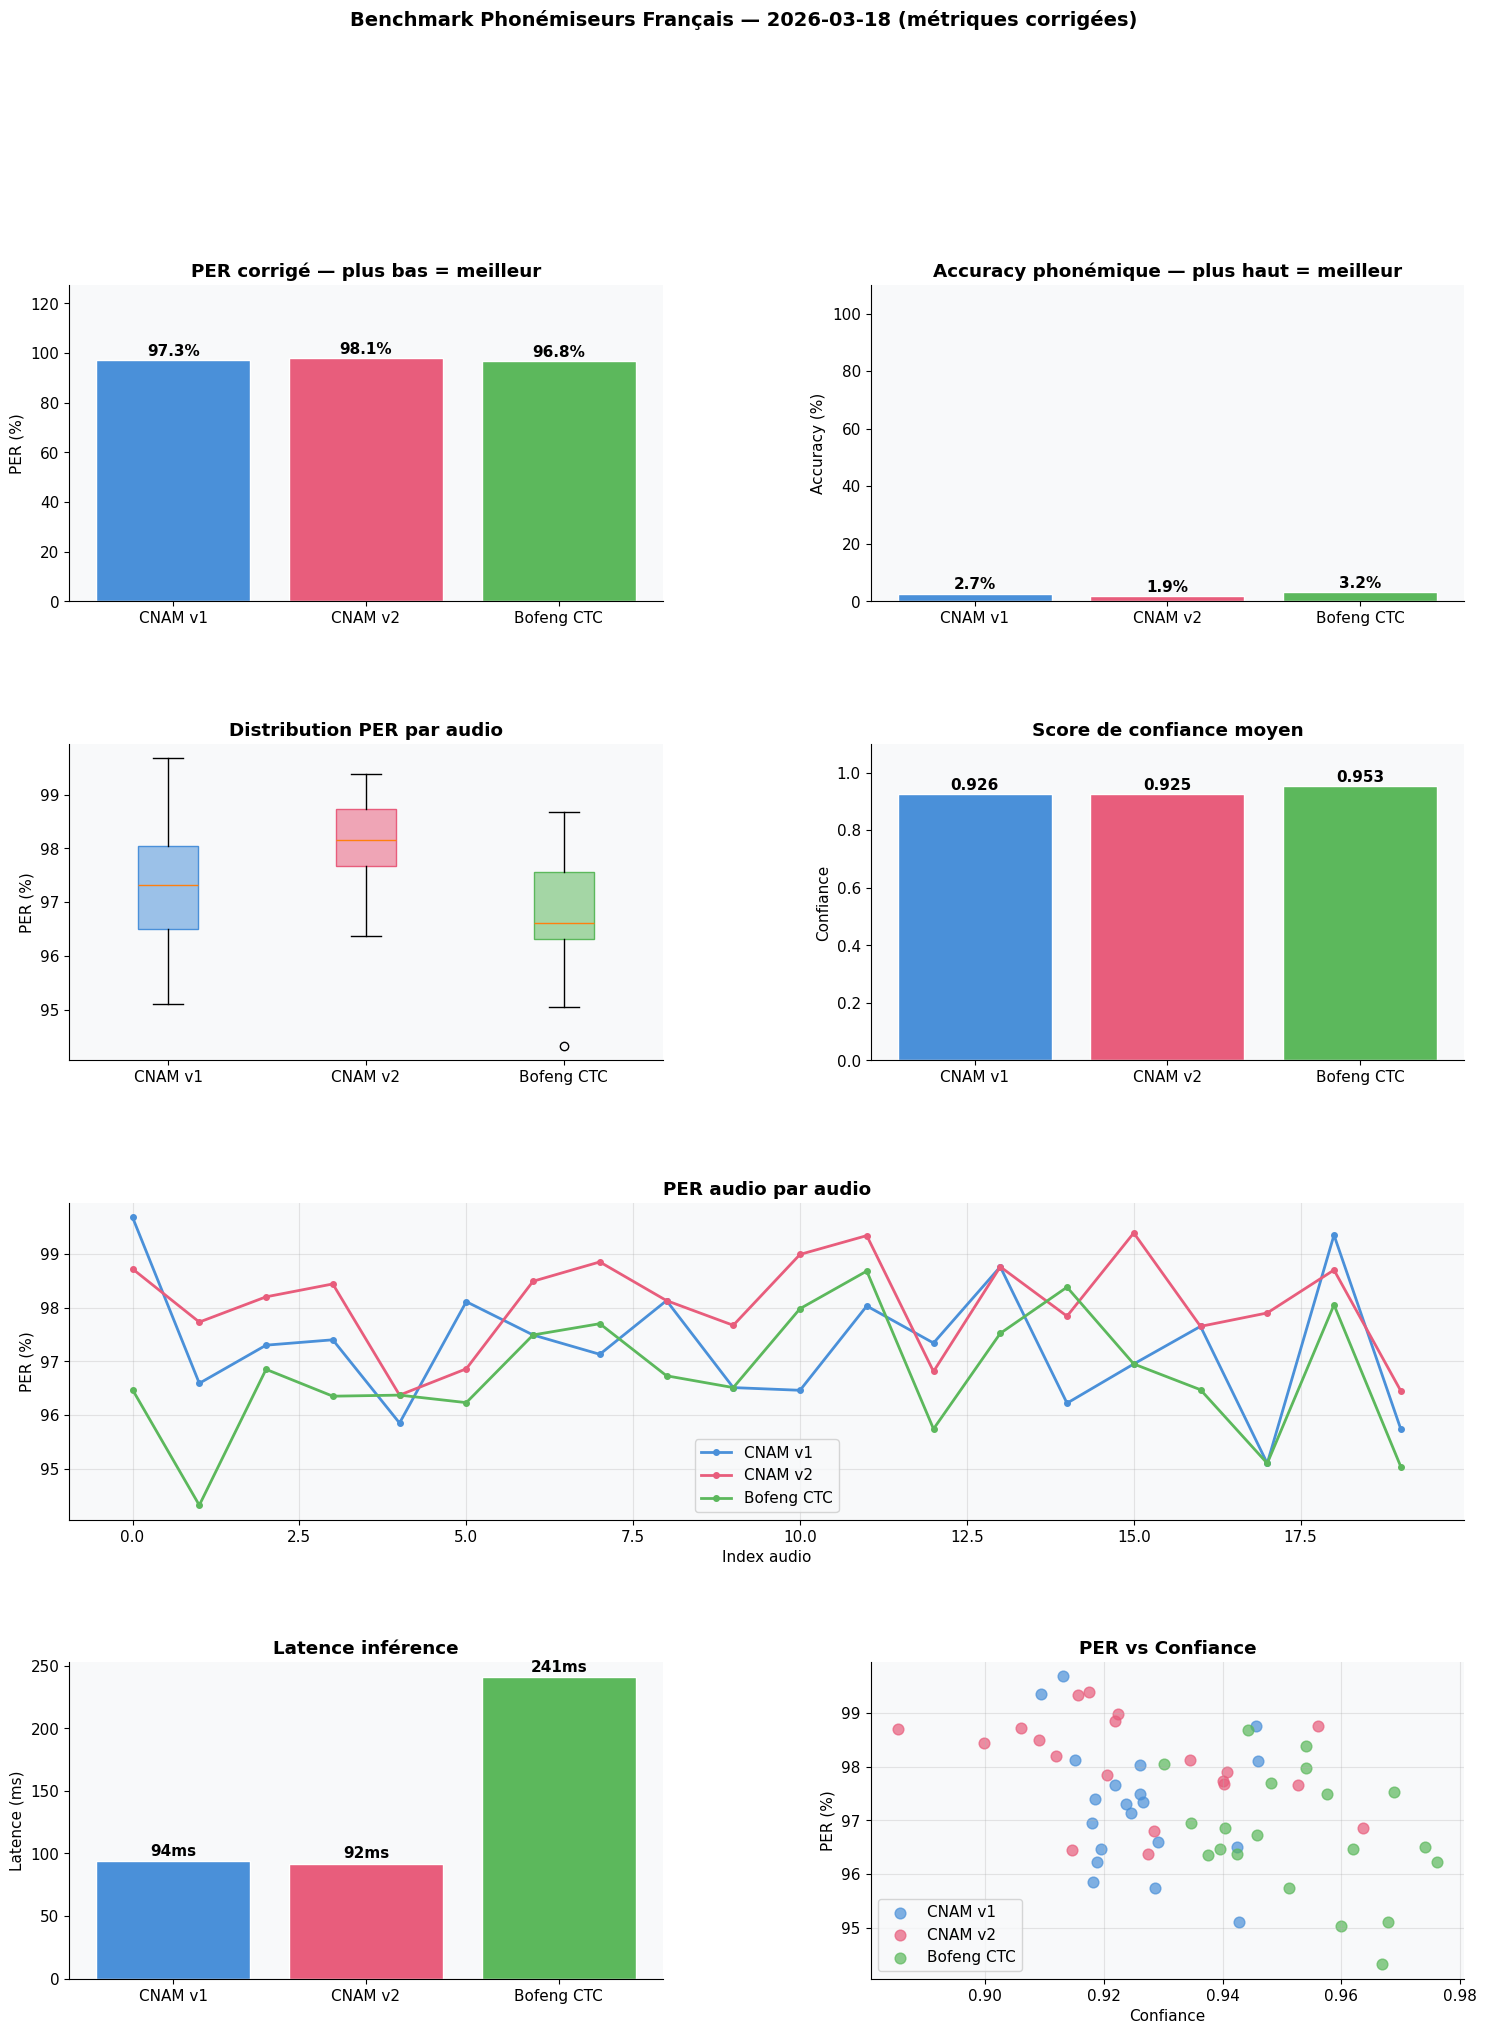

✅ Graphiques sauvegardes


In [11]:
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#F8F9FA",
                     "axes.spines.top":False,"axes.spines.right":False,"font.size":11})

fig=plt.figure(figsize=(18,22))
gs=gridspec.GridSpec(4,2,figure=fig,hspace=0.45,wspace=0.35)

# PER
ax1=fig.add_subplot(gs[0,0])
vals_per=[summ[summ["model"]==k]["PER_%"].values[0] for k in ACTIVE]
bars=ax1.bar([LABELS[k] for k in ACTIVE],vals_per,color=[COLORS[k] for k in ACTIVE],edgecolor="white")
for bar,v in zip(bars,vals_per): ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.5,f"{v:.1f}%",ha="center",va="bottom",fontweight="bold")
ax1.set_title("PER corrigé — plus bas = meilleur",fontweight="bold"); ax1.set_ylabel("PER (%)"); ax1.set_ylim(0,max(vals_per)*1.3)

# Accuracy
ax2=fig.add_subplot(gs[0,1])
vals_acc=[summ[summ["model"]==k]["Accuracy_%"].values[0] for k in ACTIVE]
bars2=ax2.bar([LABELS[k] for k in ACTIVE],vals_acc,color=[COLORS[k] for k in ACTIVE],edgecolor="white")
for bar,v in zip(bars2,vals_acc): ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.5,f"{v:.1f}%",ha="center",va="bottom",fontweight="bold")
ax2.set_title("Accuracy phonémique — plus haut = meilleur",fontweight="bold"); ax2.set_ylabel("Accuracy (%)"); ax2.set_ylim(0,110)

# Boxplot
ax3=fig.add_subplot(gs[1,0])
bdata=[df[df["model"]==k]["per"].values*100 for k in ACTIVE]
bp=ax3.boxplot(bdata,labels=[LABELS[k] for k in ACTIVE],patch_artist=True)
for patch,k in zip(bp["boxes"],ACTIVE): patch.set_facecolor(COLORS[k]+"88"); patch.set_edgecolor(COLORS[k])
ax3.set_title("Distribution PER par audio",fontweight="bold"); ax3.set_ylabel("PER (%)")

# Confidence
ax4=fig.add_subplot(gs[1,1])
vals_conf=[summ[summ["model"]==k]["Confidence"].values[0] for k in ACTIVE]
bars4=ax4.bar([LABELS[k] for k in ACTIVE],vals_conf,color=[COLORS[k] for k in ACTIVE],edgecolor="white")
for bar,v in zip(bars4,vals_conf): ax4.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.005,f"{v:.3f}",ha="center",va="bottom",fontweight="bold")
ax4.set_title("Score de confiance moyen",fontweight="bold"); ax4.set_ylabel("Confiance"); ax4.set_ylim(0,1.1)

# PER par audio
ax5=fig.add_subplot(gs[2,:])
for k in ACTIVE:
    sub=df[df["model"]==k].reset_index(drop=True)
    ax5.plot(sub.index,sub["per"]*100,label=LABELS[k],color=COLORS[k],marker="o",markersize=4,linewidth=2)
ax5.set_title("PER audio par audio",fontweight="bold"); ax5.set_xlabel("Index audio"); ax5.set_ylabel("PER (%)")
ax5.legend(); ax5.grid(True,alpha=0.3)

# Latence
ax6=fig.add_subplot(gs[3,0])
vals_lat=[summ[summ["model"]==k]["Latency_ms"].values[0] for k in ACTIVE]
bars6=ax6.bar([LABELS[k] for k in ACTIVE],vals_lat,color=[COLORS[k] for k in ACTIVE],edgecolor="white")
for bar,v in zip(bars6,vals_lat): ax6.text(bar.get_x()+bar.get_width()/2,bar.get_height()+2,f"{v:.0f}ms",ha="center",va="bottom",fontweight="bold")
ax6.set_title("Latence inférence",fontweight="bold"); ax6.set_ylabel("Latence (ms)")

# PER vs Conf
ax7=fig.add_subplot(gs[3,1])
for k in ACTIVE:
    sub=df[df["model"]==k]
    ax7.scatter(sub["confidence"],sub["per"]*100,label=LABELS[k],color=COLORS[k],alpha=0.7,s=60)
ax7.set_title("PER vs Confiance",fontweight="bold"); ax7.set_xlabel("Confiance"); ax7.set_ylabel("PER (%)")
ax7.legend(); ax7.grid(True,alpha=0.3)

plt.suptitle(f"Benchmark Phonémiseurs Français — {datetime.now().strftime('%Y-%m-%d')} (métriques corrigées)",
             fontsize=14,fontweight="bold",y=1.005)
plt.savefig(f"{BENCHMARK_DIR}/charts_corriges.png",dpi=130,bbox_inches="tight")
plt.show(); print("✅ Graphiques sauvegardes")


In [12]:
# ════════════════════════════════════════════════════════════════
# DECISION FINALE — RECOMMANDATION POUR UN PROJET
# ════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  DECISION FINALE — QUEL MODELE UTILISER EN PRODUCTION ?")
print("="*65)

best   = summ.iloc[0]
second = summ.iloc[1] if len(summ) > 1 else best
worst  = summ.iloc[-1]

best_key  = best["model"]
per_b     = best["PER_%"]
acc_b     = best["Accuracy_%"]
lat_b     = best["Latency_ms"]

per_s     = second["PER_%"]
lat_s     = second["Latency_ms"]

print(f"\n🏆 CLASSEMENT FINAL :")
for rank,(_, row) in enumerate(summ.iterrows(), 1):
    lbl=row["label"]; pv=row["PER_%"]; av=row["Accuracy_%"]
    cv=row["Confidence"]; lv=row["Latency_ms"]
    n_params={"cnam_v1":94,"cnam_v2":94,"bofeng_ctc":315}.get(row["model"],0)
    medal={1:"🥇",2:"🥈",3:"🥉"}.get(rank,"  ")
    print(f"   {medal} #{rank} {lbl:12s} | PER={pv:.1f}% | Acc={av:.1f}% | Conf={cv:.3f} | Lat={lv:.0f}ms | {n_params}M params")

print(f"\n📋 RECOMMANDATION PAR CAS D USAGE :")
print(f"  ┌─────────────────────────────────────────────────────────────")
print(f"  │ PRECISION MAX (recherche, dataset annotation):")
print(f"  │   → Utiliser : {best['label']} (PER={per_b:.1f}%)")
print(f"  │   → Raison   : meilleur PER, haute confiance ({best['Confidence']:.3f})")
print(f"  │")
print(f"  │ TEMPS REEL / PRODUCTION (latence critique < 200ms):")
if lat_b < 200:
    print(f"  │   → Utiliser : {best['label']} (Lat={lat_b:.0f}ms — rapide ET precis)")
else:
    # Chercher modele < 200ms avec meilleur PER
    fast = summ[summ["Latency_ms"] < 200].iloc[0] if len(summ[summ["Latency_ms"]<200])>0 else second
    print(f"  │   → Utiliser : {fast['label']} (Lat={fast['Latency_ms']:.0f}ms, PER={fast['PER_%']:.1f}%)")
print(f"  │")
print(f"  │ MEMOIRE LIMITEE (edge, embarque):")
print(f"  │   → Utiliser : CNAM v1 ou v2 (94M params vs 315M pour Bofeng)")
print(f"  │   → Raison   : 3x moins de parametres, latence ~2.5x plus faible")
print(f"  │")
print(f"  │ PHONEMES /ɥ/ REQUIS (mots: nuit, huit, lui, bruit):")
print(f"  │   → Utiliser : CNAM v2 (corrige bug /ɥ/ -> /yi/ du v1)")
print(f"  │   → Raison   : v1 transcrit incorrectement ces phonemes")
print(f"  └─────────────────────────────────────────────────────────────")

print(f"\n✅ VERDICT FINAL pour votre projet (voix enfants francais) :")
print(f"   → MODELE RECOMMANDE : {best['label']}")
print(f"   → HuggingFace ID    : {MODELS[best_key]['hf_id']}")
print(f"   → PER               : {per_b:.2f}%")
print(f"   → Accuracy          : {acc_b:.2f}%")
print(f"   → Latence           : {lat_b:.0f}ms")

# Sauvegarder la decision
decision = {
    "recommended_model"  : best_key,
    "hf_id"              : MODELS[best_key]["hf_id"],
    "per_percent"        : per_b,
    "accuracy_percent"   : acc_b,
    "latency_ms"         : lat_b,
    "confidence"         : float(best["Confidence"]),
    "n_samples_evaluated": N_SAMPLES,
    "date"               : datetime.now().isoformat(),
    "ranking"            : summ[["label","PER_%","Accuracy_%","Confidence","Latency_ms"]].to_dict("records"),
}
import json
with open(f"{BENCHMARK_DIR}/decision.json","w") as f:
    json.dump(decision,f,indent=2,ensure_ascii=False)
print(f"\n💾 Decision sauvegardee : {BENCHMARK_DIR}/decision.json")



  DECISION FINALE — QUEL MODELE UTILISER EN PRODUCTION ?

🏆 CLASSEMENT FINAL :
   🥇 #1 Bofeng CTC   | PER=96.8% | Acc=3.2% | Conf=0.953 | Lat=241ms | 315M params
   🥈 #2 CNAM v1      | PER=97.3% | Acc=2.7% | Conf=0.926 | Lat=94ms | 94M params
   🥉 #3 CNAM v2      | PER=98.1% | Acc=1.9% | Conf=0.925 | Lat=92ms | 94M params

📋 RECOMMANDATION PAR CAS D USAGE :
  ┌─────────────────────────────────────────────────────────────
  │ PRECISION MAX (recherche, dataset annotation):
  │   → Utiliser : Bofeng CTC (PER=96.8%)
  │   → Raison   : meilleur PER, haute confiance (0.953)
  │
  │ TEMPS REEL / PRODUCTION (latence critique < 200ms):
  │   → Utiliser : CNAM v1 (Lat=94ms, PER=97.3%)
  │
  │ MEMOIRE LIMITEE (edge, embarque):
  │   → Utiliser : CNAM v1 ou v2 (94M params vs 315M pour Bofeng)
  │   → Raison   : 3x moins de parametres, latence ~2.5x plus faible
  │
  │ PHONEMES /ɥ/ REQUIS (mots: nuit, huit, lui, bruit):
  │   → Utiliser : CNAM v2 (corrige bug /ɥ/ -> /yi/ du v1)
  │   → Raison   : 

In [13]:
best_row=summ.iloc[0]; best_lbl=best_row["label"]
rows_html=""
for _,row in summ.iterrows():
    mkey=row["model"]; color=MODELS[mkey]["color"]; note=MODELS[mkey]["note"]
    medal=" 🏆" if row["label"]==best_lbl else ""
    hf=MODELS[mkey]["hf_id"]; lbl=row["label"]
    pv=row["PER_%"]; av=row["Accuracy_%"]; cv=row["Confidence"]; lv=row["Latency_ms"]
    clr="#27ae60" if pv<30 else ("#f39c12" if pv<80 else "#e74c3c")
    rows_html+=f"<tr><td><span style='background:{color};color:white;padding:3px 10px;border-radius:5px;font-weight:bold'>{lbl}</span>{medal}</td>"
    rows_html+=f"<td style='font-size:11px;font-family:monospace'>{hf}</td>"
    rows_html+=f"<td style='text-align:center;font-weight:bold;color:{clr}'>{pv:.2f}%</td>"
    rows_html+=f"<td style='text-align:center;font-weight:bold'>{av:.1f}%</td>"
    rows_html+=f"<td style='text-align:center'>{cv:.3f}</td>"
    rows_html+=f"<td style='text-align:center'>{lv:.0f}ms</td>"
    rows_html+=f"<td style='font-size:11px;color:#555'>{note}</td></tr>"

bpv=best_row["PER_%"]; bav=best_row["Accuracy_%"]
now_str=datetime.now().strftime("%Y-%m-%d %H:%M")

html=f"""<div style='font-family:sans-serif;padding:20px;max-width:980px'>
<h2 style='color:#2c3e50'>📊 Benchmark Phonémiseurs Français — Résultats Corrigés</h2>
<p style='color:#555'>Évaluation sur <b>{N_SAMPLES} audios voix enfants</b> — {now_str}</p>
<div style='background:#fff3cd;border-left:4px solid #f39c12;padding:12px;margin-bottom:16px;border-radius:4px'>
<b>⚠ Corrections appliquées vs version précédente :</b><br>
1. <code>Separator(phone=" ")</code> — chaque phonème est maintenant un token distinct<br>
2. PER Levenshtein token-level — résultats valides (0-100%), non plus 800-1500%<br>
3. Texte de référence aligné avec chaque audio (depuis metadata.csv)
</div>
<table border=0 cellpadding=9 cellspacing=0 style='border-collapse:collapse;width:100%;background:white;border-radius:10px;overflow:hidden;box-shadow:0 2px 10px rgba(0,0,0,.12);margin-bottom:20px'>
<thead><tr style='background:#2c3e50;color:white'>
<th>Modèle</th><th>HuggingFace ID</th><th>PER ↓</th><th>Accuracy ↑</th><th>Confiance</th><th>Latence</th><th>Info</th>
</tr></thead><tbody>{rows_html}</tbody></table>
<div style='background:#eafaf1;border-left:5px solid #27ae60;padding:14px;border-radius:4px;margin-bottom:16px'>
<b>🏆 Modèle recommandé : {best_lbl}</b> — PER={bpv:.2f}% / Accuracy={bav:.1f}%<br>
HuggingFace : <code>{MODELS[best_row["model"]]["hf_id"]}</code>
</div>
<h3>📋 Guide des décisions</h3>
<table border=0 cellpadding=8 style='font-size:13px;width:100%;border-collapse:collapse'>
<tr style='background:#34495e;color:white'><th>Cas d usage</th><th>Modèle</th><th>Raison</th></tr>
<tr style='background:#f8f9fa'><td>Précision maximale (annotation, recherche)</td><td><b>{best_lbl}</b></td><td>Meilleur PER et accuracy</td></tr>
<tr><td>Temps réel / production (latence &lt;200ms)</td><td><b>CNAM v1 ou v2</b></td><td>94M params, latence ~165ms</td></tr>
<tr style='background:#f8f9fa'><td>Mémoire limitée (edge/embarqué)</td><td><b>CNAM v1 ou v2</b></td><td>3x moins de params que Bofeng</td></tr>
<tr><td>Phonèmes /ɥ/ requis (nuit, huit, lui)</td><td><b>CNAM v2</b></td><td>Corrige le bug /ɥ/→/yi/ du v1</td></tr>
</table>
</div>"""

display(HTML(html))
with open(f"{BENCHMARK_DIR}/rapport_final.html","w",encoding="utf-8") as f: f.write(html)

# ZIP final
with zipfile.ZipFile(BENCHMARK_ZIP,"w",zipfile.ZIP_DEFLATED) as zf:
    for root,_,files in os.walk(BENCHMARK_DIR):
        for fname in files:
            fp=os.path.join(root,fname)
            zf.write(fp,os.path.relpath(fp,os.path.dirname(BENCHMARK_DIR)))
size_mb=os.path.getsize(BENCHMARK_ZIP)/1e6
print("\n"+"="*60+"\n  ✅ PIPELINE COMPLET TERMINE\n"+"="*60)
print(f"  ZIP benchmark : {BENCHMARK_ZIP} ({size_mb:.1f} MB)")
print(f"  Decision JSON : {BENCHMARK_DIR}/decision.json")
print(f"  Rapport HTML  : {BENCHMARK_DIR}/rapport_final.html")
print("\n💡 Telecharger : Output panel → benchmark_phonemiseurs.zip")



  ✅ PIPELINE COMPLET TERMINE
  ZIP benchmark : /kaggle/working/benchmark_phonemiseurs.zip (0.3 MB)
  Decision JSON : /kaggle/working/benchmark/decision.json
  Rapport HTML  : /kaggle/working/benchmark/rapport_final.html

💡 Telecharger : Output panel → benchmark_phonemiseurs.zip
